In [ ]:
%pip install -r ./requirements.txt

In [56]:
import re
from pathlib import Path
import requests
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
import nltk
import spacy
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from gensim.models import Word2Vec
import numpy as np

In [ ]:
# Q1:

BOOKS: dict[int, str] = {
    2701: "Moby Dick",
    1342: "Pride and Prejudice",
    84: "Frankenstein",
    1661: "The Adventures of Sherlock Holmes",
    11: "Alice's Adventures in Wonderland",
    74: "The Adventures of Tom Sawyer",
    98: "A Tale of Two Cities",
    1232: "The Prince",
    5200: "Metamorphosis",
    1952: "The Yellow Wallpaper",
}

DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

def download_book(book_id: int) -> str | None:
    url: str = f"https://www.gutenberg.org/cache/epub/{book_id}/pg{book_id}.txt"
    response = requests.get(url = url, timeout=20)
    if response.status_code == 200:
        response.encoding = "utf-8"
        return response.text
    return None

def remove_boilerplate(book_name: str, book_text: str) -> str:
    start_pattern: str = fr"\*\*\* START OF THE PROJECT GUTENBERG EBOOK {book_name.upper()}.*?\*\*\*"
    end_pattern: str = fr"\*\*\* END OF THE PROJECT GUTENBERG EBOOK {book_name.upper()}.*?\*\*\*"
    book_text = re.sub(r"\r\n", "\n", book_text) # replaces all windows-style line-endings to unix-like
    start_match: re.Match[str] | None = re.search(start_pattern, book_text, flags=re.IGNORECASE | re.DOTALL)
    end_match: re.Match[str] | None = re.search(end_pattern, book_text, flags=re.IGNORECASE | re.DOTALL)
    start_index = start_match.end() if start_match is not None else 0
    end_index = end_match.start() if end_match is not None else len(book_text)
    book_text = book_text[start_index:end_index]
    return book_text.strip()

def write_book_to_file(book_id: int, text: str):
    path = DATA_DIR / f"{book_id}.txt"
    path.write_text(data = text, encoding="utf-8")
    print(f"Book: {BOOKS.get(book_id)} with id: {book_id}. File Size = {round(path.stat().st_size / 1024, 2)}kB. Beggining = {text[:100].replace("\n", "")}")

DOWNLOAD_BASE_URL = 'www.gutenberg.org/ebooks'
def download_books() -> dict[int, str]:
    book_dict: dict[int,str] = {}
    for book_id, book_name in BOOKS.items():
        result = download_book(book_id=book_id)
        if result is None:
            raise ValueError(f"failure during downloading of book {book_id}")
        text = remove_boilerplate(book_name=book_name, book_text=result)
        book_dict[book_id] = text
    return book_dict
        
        
book_dict: dict[str, int] = download_books()
for book_id, book_text in book_dict.items():
    write_book_to_file(book_id, book_text)

In [ ]:
# Q2
# \b means it touches a word boundary
CONTRACTIONS = {
    r"\bdon't\b": "do not",
    r"\bcan't\b": "cannot",
    r"\bwon't\b": "will not",
    r"\bit's\b": "it is",
    r"\bi'm\b": "i am",
    r"\bi've\b": "i have",
    r"\bi'll\b": "i will",
    r"\bthat's\b": "that is",
    r"\bthere's\b": "there is",
    r"\bi'd\b": "i would"
}


def to_lower(book_text: str) -> str:
    return book_text.lower()

def normalize_contractions(book_text: str) -> str:
    for pattern, replacement in CONTRACTIONS.items():
        book_text = re.sub(pattern, replacement, book_text, flags=re.IGNORECASE)
    return book_text

def normalize_whitespaces(book_text: str) -> str:
    book_text = re.sub(r"\s+", " ", book_text)
    return book_text

def remove_special_characters(book_text: str) -> str:
    return re.sub(r"[^a-zA-Z\s]", "", book_text)

def find_ing_words(text: str) -> list[str]:
    return re.findall(r"\b[a-zA-Z]+ing\b", text)

def normalize_text(book_text: str) -> str:
    book_text = to_lower(book_text)
    book_text = normalize_whitespaces(book_text)
    book_text = normalize_contractions(book_text)
    book_text = remove_special_characters(book_text)
    return book_text

def extract_sentences_with_keyword(book_text: str, keyword: str) -> list[str]:
    pattern = rf"[^.!?]*\b{re.escape(keyword)}\b[^.!?]*[.!?][\"”’']?"
    sentences = re.findall(pattern, book_text, flags=re.IGNORECASE)
    return [normalize_whitespaces(sentence).strip() for sentence in sentences]

def find_words(book_text: str) -> list[str]:
    return re.findall(r"\b[a-zA-Z]+\b", book_text)

keyword = "monster"
for book_id, book_text in book_dict.items():
    sentences = extract_sentences_with_keyword(book_text, keyword)
    print(f"\nBook: {BOOKS.get(book_id)}")
    print(f"Sentences with '{keyword}': {len(sentences)}")
    for sentence in sentences[:3]:
        print("-", sentence)

print("\n")

for book_id, book_text in book_dict.items():
    book_text = normalize_text(book_text)
    words: list[str] = find_ing_words(text = book_text)
    print(f"Words ending with -ing in a book {BOOKS.get(book_id)}: {words[:10]}. Total {len(words)}.")

print("\n")

ing_frequency_records = []
for book_id, book_text in book_dict.items():
    book_text = normalize_text(book_text)
    ing_words = find_ing_words(book_text)
    ing_counts = Counter(ing_words)
    for word, frequency in ing_counts.most_common(20):
        ing_frequency_records.append({
            "book_id": book_id,
            "title": BOOKS.get(book_id),
            "word": word,
            "frequency": frequency
        })

word_frequency_records = []
for book_id, book_text in book_dict.items():
    normalized_text = normalize_text(book_text)
    words = find_words(normalized_text)
    word_counts = Counter(words)
    for word, frequency in word_counts.most_common(20):
        word_frequency_records.append({
            "book_id": book_id,
            "title": BOOKS.get(book_id),
            "word": word,
            "frequency": frequency
        })

word_frequency_df = pd.DataFrame(word_frequency_records)
word_frequency_df = word_frequency_df.sort_values(by="frequency", ascending=False).reset_index(drop=True)
word_frequency_df.head(20)

def visualise_top_terms(book_id: int, num_terms: int):
    if num_terms < 1:
        raise ValueError("num_terms must be >= 1")
    selected_words_df = word_frequency_df[word_frequency_df["book_id"] == book_id].sort_values(by="frequency", ascending=False).head(num_terms)
    plt.figure(figsize=(10, 5))
    plt.bar(selected_words_df["word"], selected_words_df["frequency"])
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Top {num_terms} terms in {BOOKS.get(book_id)}")
    plt.xlabel("Term")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

first_book_id = next(iter(BOOKS))
visualise_top_terms(first_book_id, num_terms=20)

In [ ]:
!python -m spacy download en_core_web_sm

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /home/shuptik/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/shuptik/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


,book_id,title,nltk_word_tokens,spacy_word_tokens,nltk_sentence_tokens,spacy_sentence_tokens,nltk_tokens_after_stopword_filtering,spacy_tokens_after_stopword_filtering
0,2701,Moby Dick,258699,260546,9064,9993,105069,95698
1,1342,Pride and Prejudice,151020,152543,4795,6215,55254,47166
2,84,Frankenstein,85539,85881,3075,3335,34160,30507
3,1661,The Adventures of Sherlock Holmes,125463,127667,4716,6652,44192,39180
4,11,Alice's Adventures in Wonderland,35021,35157,984,1527,11848,10357
5,74,The Adventures of Tom Sawyer,90483,89982,3666,4911,33547,30022
6,98,A Tale of Two Cities,166840,168428,5622,7536,61391,55022
7,1232,The Prince,56762,56843,1285,1358,22261,19075
8,5200,Metamorphosis,25292,25031,731,782,9915,7974
9,1952,The Yellow Wallpaper,7247,7181,376,396,2596,2140


,book_id,title,word,frequency,library
0,2701,Moby Dick,whale,1080,NLTK
1,2701,Moby Dick,one,912,NLTK
2,2701,Moby Dick,like,581,NLTK
3,2701,Moby Dick,upon,565,NLTK
4,2701,Moby Dick,ahab,510,NLTK
5,2701,Moby Dick,man,491,NLTK
6,2701,Moby Dick,ship,468,NLTK
7,2701,Moby Dick,ye,463,NLTK
8,2701,Moby Dick,old,443,NLTK
9,2701,Moby Dick,would,430,NLTK


,book_id,title,word,frequency,library
0,2701,Moby Dick,whale,1232,spaCy
1,2701,Moby Dick,like,645,spaCy
2,2701,Moby Dick,man,522,spaCy
3,2701,Moby Dick,ship,517,spaCy
4,2701,Moby Dick,ahab,504,spaCy
5,2701,Moby Dick,sea,454,spaCy
6,2701,Moby Dick,old,449,spaCy
7,2701,Moby Dick,ye,429,spaCy
8,2701,Moby Dick,head,346,spaCy
9,2701,Moby Dick,boat,335,spaCy


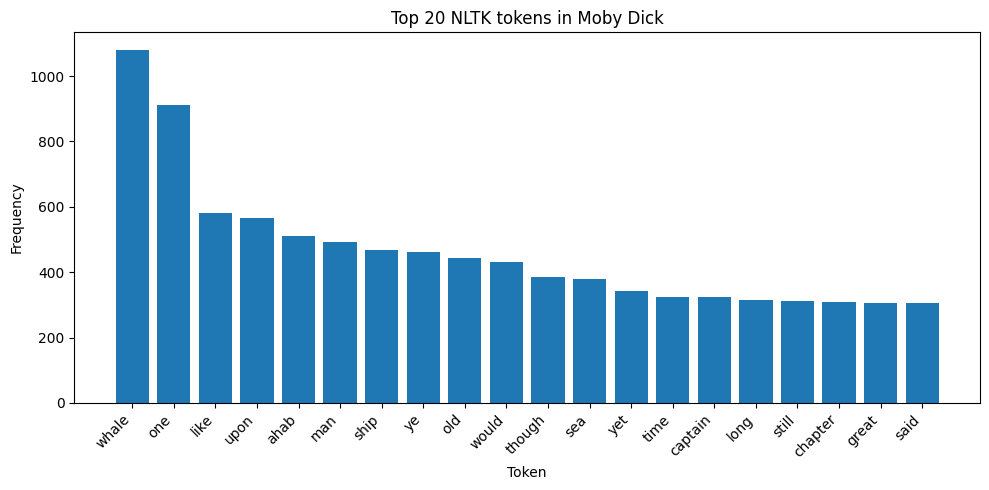

In [55]:
# Q3:
nlp = spacy.load("en_core_web_sm")
nlp.max_length = 5000000
nltk.download('punkt_tab')
nltk.download("stopwords")

def nltk_word_tokens(book_text: str) -> list[str]:
    text = normalize_whitespaces(book_text)
    return word_tokenize(text)


def nltk_sentence_tokens(book_text: str) -> list[str]:
    text = normalize_whitespaces(book_text)
    return sent_tokenize(text)

english_stopwords = set(stopwords.words("english"))
def filter_nltk_tokens(tokens: list[str]) -> list[str]:
    return [
        token.lower()
        for token in tokens
        if token.isalpha() and token.lower() not in english_stopwords
    ]

def spacy_doc(book_text: str):
    text = normalize_whitespaces(book_text)
    return nlp(text)

def spacy_word_tokens(doc) -> list[str]:
    return [token.text for token in doc]

def spacy_sentence_tokens(doc) -> list[str]:
    return [sentence.text for sentence in doc.sents]

def filter_spacy_tokens(doc) -> list[str]:
    return [token.text.lower()
        for token in doc
        if token.is_alpha and not token.is_stop]

tokenization_records = []
nltk_frequency_records = []
spacy_frequency_records = []
for book_id, book_text in book_dict.items():
    nltk_words = nltk_word_tokens(book_text)
    nltk_sentences = nltk_sentence_tokens(book_text)
    nltk_filtered = filter_nltk_tokens(nltk_words)
    nltk_counts = Counter(nltk_filtered)

    for word, frequency in nltk_counts.most_common(20):
        nltk_frequency_records.append({
            "book_id": book_id,
            "title": BOOKS.get(book_id),
            "word": word,
            "frequency": frequency,
            "library": "NLTK"
        })

    doc = spacy_doc(book_text)
    spacy_words = spacy_word_tokens(doc)
    spacy_sentences = spacy_sentence_tokens(doc)
    spacy_filtered = filter_spacy_tokens(doc)
    spacy_counts = Counter(spacy_filtered)

    for word, frequency in spacy_counts.most_common(20):
        spacy_frequency_records.append({
            "book_id": book_id,
            "title": BOOKS.get(book_id),
            "word": word,
            "frequency": frequency,
            "library": "spaCy"
        })

    tokenization_records.append({
        "book_id": book_id,
        "title": BOOKS.get(book_id),
        "nltk_word_tokens": len(nltk_words),
        "spacy_word_tokens": len(spacy_words),
        "nltk_sentence_tokens": len(nltk_sentences),
        "spacy_sentence_tokens": len(spacy_sentences),
        "nltk_tokens_after_stopword_filtering": len(nltk_filtered),
        "spacy_tokens_after_stopword_filtering": len(spacy_filtered),
    })
    
tokenization_df = pd.DataFrame(tokenization_records)
nltk_frequency_df = pd.DataFrame(nltk_frequency_records)
spacy_frequency_df = pd.DataFrame(spacy_frequency_records)
display(tokenization_df.head(20))
display(nltk_frequency_df.head(20))
display(spacy_frequency_df.head(20))

def visualise_top_nltk_tokens(book_id: int, num_terms: int = 20):
    if num_terms < 1:
        raise ValueError("num_terms must be >= 1")
    selected_df = nltk_frequency_df[nltk_frequency_df["book_id"] == book_id].sort_values(by="frequency", ascending=False).head(num_terms)
    plt.figure(figsize=(10, 5))
    plt.bar(selected_df["word"], selected_df["frequency"])
    plt.xticks(rotation=45, ha="right")
    plt.title(f"Top {num_terms} NLTK tokens in {BOOKS.get(book_id)}")
    plt.xlabel("Token")
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

visualise_top_nltk_tokens(first_book_id, num_terms=20)

In [57]:
book_ids = list(book_dict.keys())
book_names = [BOOKS[book_id] for book_id in book_ids]
documents = [normalize_text(book_dict[book_id]) for book_id in book_ids]

bow_vectorizer = CountVectorizer(max_features=10000)
bow_matrix = bow_vectorizer.fit_transform(documents)
print(bow_matrix.shape)

bow_df = pd.DataFrame(
    bow_matrix.toarray(),
    index=book_names,
    columns=bow_vectorizer.get_feature_names_out()
)

def show_top_bow_terms(book_title: str, num_terms: int = 20):
    row = bow_df.loc[book_title]
    top_terms = row.sort_values(ascending=False).head(num_terms)
    return pd.DataFrame({
        "word": top_terms.index,
        "count": top_terms.values
    })

word_count_df = show_top_bow_terms(BOOKS.get(first_book_id), 20)
display(word_count_df.head(50))

(10, 10000)


,word,count
0,the,14423
1,of,6593
2,and,6379
3,to,4579
4,in,4155
5,that,2940
6,his,2522
7,it,2368
8,but,1776
9,he,1749
